## 파이썬 활용 휴머노이드 연구동향 분석


### 연구 절차

⛺ Part1

1. 논문 수집   
 - 검색어 : `휴머노이드`
 - `requests`, `beautifulsoup` 라이브러리 활용
 - https://wwww.riss.kr 에서 **학술, 학위** 논문 수집
 - https://www.kci.go.kr/ 에서 **학술논문** 수집  
 (KCI 검색어 규칙) https://www.kci.go.kr/kciportal/po/search/poArtiSear.kci
 -> 고급검색 -> 검색쿼리? 클릭

2. 분석대상 논문 선택  
 - 데이터 병합 (riss와 kci에서 수집한 학술, 학위 논문을 하나의 데이터로 만듬)
 - 중복 논문 제거
 - 관련 없는 논문 제거
    - ex) *제목과 초록에 휴머노이드 또는 Humanoid란 단어가 없는 논문*
 - 최종 filtered 논문 저장

3. 연구 동향 파악
 - 연도별 논문수 분석/시각화
 - 학회별 논문수 분석/시각화
 - 대학별 논문수 분석/시각화
 - 학위별 논문수 분석/시각화



In [ ]:
# import this

### 1.논문 수집

In [ ]:
# 키워드 설정 - 검색할 단어를 따옴표 안에 적는다.
keyword = "((생성형AI)|(생성)|(ChatGPT)|(챗GPT)) ((인공지능)|(AI)) ((교육)|(수업))"
kci_keyword = "(생성형AI|생성|ChatGPT|챗GPT) AND (인공지능|AI) AND (교육|수업)"

In [ ]:
# 구글 드라이브 연동
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


🚀 코랩의 코드셀에서 **생성**을 누르고 코드생성 프롬프트를 작성하면 자동으로 코드가 생성된다!!!
- 코드 셀에서 생성을 클릭하고 원하는 프롬프트를 작성하고 엔터를 치면, 아래에 자동으로 코드 셀이 추가되면서 코드가 생성된다.

In [ ]:
# prompt: keyword 변수값으로 구글드라이브에 폴더 생성

import os

folder_path = f'/content/drive/MyDrive/{keyword}'

# Check if the folder already exists
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{keyword}' created successfully in Google Drive.")
else:
    print(f"Folder '{keyword}' already exists in Google Drive.")

Folder '((생성형AI)|(생성)|(ChatGPT)|(챗GPT)) ((인공지능)|(AI)) ((교육)|(수업))' created successfully in Google Drive.


✅ 구글드라이브에 휴머노이드 폴더가 생겼는지 확인해보세요.

#### 1.1) riss.kr에서 학술논문 수집

In [ ]:
'''학술논문 크롤링 함수 정의
1) 전체 논문수 확인 함수
2) 논문 크롤링 후 csv 파일로 저장하는 함수
'''

import os
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

def get_total_papers_count_hs(search_keyword, start_count=0):
    """전체 검색된 논문 수를 가져오는 함수"""
    base_url = f"https://www.riss.kr/search/Search.do?isDetailSearch=N&searchGubun=true&viewYn=OP&query={search_keyword}\
&queryText=&iStartCount={start_count}&iGroupView=5&icate=all&colName=re_a_kor&exQuery=&exQueryText=&order=%2FDESC&onHanja=false&strSort=RANK&pageScale=100\
&orderBy=&fsearchMethod=&isFDetailSearch=N&sflag=1&searchQuery={search_keyword}&fsearchSort=&fsearchOrder=&limiterList=&limiterListText=\
&facetList=&facetListText=&fsearchDB=&resultKeyword=&pageNumber=1&p_year1=&p_year2=&dorg_storage=&mat_type=&mat_subtype=&fulltext_kind=\
&t_gubun=&learning_type=&language_code=&ccl_code=&language=&inside_outside=&fric_yn=&db_type=&image_yn=&regnm=&gubun=&kdc=&ttsUseYn="
    response = requests.get(base_url)
    soup = BeautifulSoup(response.content, 'html.parser')

    # 전체 검색된 논문 수 추출
    total_papers_tag = soup.find('span', class_='num')
    if total_papers_tag:
        total_papers = int(total_papers_tag.text.replace(',', ''))  # 숫자에 있는 콤마 제거 후 int 변환
        return total_papers

    else:
        return 0

def crawl_papers_hs(search_keyword, max_papers=total_papers):
    """논문 정보를 크롤링하는 함수 (최대 max_papers 수집)"""
    # 논문 수 확인
    total_papers = get_total_papers_count_hs(search_keyword)
    print(f"전체 검색된 논문 수: {total_papers}개")

    # 수집할 논문 수 결정 (최대 1000개 혹은 검색된 논문 수)
    papers_to_collect = min(max_papers, total_papers)
    print(f"수집할 논문 수: {papers_to_collect}개")

    # 수집할 데이터 저장 리스트 초기화
    title, writer, publisher, year, journal, link, abstracts = [], [], [], [], [], [], []

    # 페이지별로 논문 데이터 수집
    for start_count in range(0, papers_to_collect, 100):
        # 각 페이지의 URL
        page_url = f"https://www.riss.kr/search/Search.do?isDetailSearch=N&searchGubun=true&viewYn=OP&query={search_keyword}\
&queryText=&iStartCount={start_count}&iGroupView=5&icate=all&colName=re_a_kor&exQuery=&exQueryText=&order=%2FDESC&onHanja=false&strSort=RANK&pageScale=100\
&orderBy=&fsearchMethod=&isFDetailSearch=N&sflag=1&searchQuery={search_keyword}&fsearchSort=&fsearchOrder=&limiterList=&limiterListText=\
&facetList=&facetListText=&fsearchDB=&resultKeyword=&pageNumber=1&p_year1=&p_year2=&dorg_storage=&mat_type=&mat_subtype=&fulltext_kind=\
&t_gubun=&learning_type=&language_code=&ccl_code=&language=&inside_outside=&fric_yn=&db_type=&image_yn=&regnm=&gubun=&kdc=&ttsUseYn="
        response = requests.get(page_url)
        soup = BeautifulSoup(response.content, 'html.parser')

        # 논문 정보가 담긴 컨테이너 가져오기
        contents = soup.find_all('div', class_='cont ml60')

        for cont in contents:
            title.append(cont.find('p', class_='title').text.strip())
            writer.append(cont.find('span', class_='writer').text.strip())
            publisher.append(cont.find('p', class_="etc").find_all('span')[1].text.strip())
            year.append(cont.find('p', class_="etc").find_all('span')[2].text.strip())
            journal.append(cont.find('p', class_="etc").find_all('span')[3].text.strip())
            link.append('https://www.riss.kr' + cont.find('p', class_='title').find('a')['href'].strip())

            # 초록이 있을 경우와 없을 경우 처리
            if cont.find('p', class_='preAbstract'):
                abstracts.append(cont.find('p', class_='preAbstract').text.strip())
            else:
                abstracts.append('초록이 없습니다.')

        time.sleep(1)

        # 수집된 논문 수가 목표치에 도달하면 중단
        if len(title) >= papers_to_collect:
            break

    # pandas DataFrame으로 변환
    df = pd.DataFrame({
        'Title': title[:papers_to_collect],
        'Writer': writer[:papers_to_collect],
        'Publisher': publisher[:papers_to_collect],
        'Year': year[:papers_to_collect],
        'Journal': journal[:papers_to_collect],
        'Abstract': abstracts[:papers_to_collect],
        'Link': link[:papers_to_collect]
    })

    folder_path = f'/content/drive/MyDrive/{search_keyword}'

    # Check if the folder already exists
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f"Folder '{search_keyword}' created successfully in Google Drive.")
    else:
        print(f"Folder '{search_keyword}' already exists in Google Drive.")

    # CSV 파일과 Excel 파일로 저장
    csv_file = os.path.join(folder_path, f"{search_keyword}_학술논문(riss).csv")
    # excel_file = os.path.join(folder_path, f"{search_keyword}_학술논문}.xlsx")

    df.to_csv(csv_file, index=False, encoding='utf-8-sig')
    # df.to_excel(excel_file, index=False, engine='openpyxl')

    print(f"CSV 파일이 {csv_file}에 저장되었습니다.")
    # print(f"Excel 파일이 {excel_file}에 저장되었습니다.")

In [ ]:
# 키워드로 검색된 학술논문 수 확인
total_papers = get_total_papers_count_hs(keyword)
print(f"전체 검색된 학술논문 수: {total_papers}개")

전체 검색된 학술논문 수: 2265개


In [ ]:
# keyword로 학술논문 수집 -> 구글 드라이브 keyword 폴더에 keyword_학술논문 파일로 자동저장
crawl_papers_hs(keyword)

전체 검색된 논문 수: 2265개
수집할 논문 수: 2265개
Folder '((생성형AI)|(생성)|(ChatGPT)|(챗GPT)) ((인공지능)|(AI)) ((교육)|(수업))' already exists in Google Drive.
CSV 파일이 /content/drive/MyDrive/((생성형AI)|(생성)|(ChatGPT)|(챗GPT)) ((인공지능)|(AI)) ((교육)|(수업))/((생성형AI)|(생성)|(ChatGPT)|(챗GPT)) ((인공지능)|(AI)) ((교육)|(수업))_학술논문(riss).csv에 저장되었습니다.


In [ ]:
# 수집된 논문 기본 정보 확인하기
df_hs = pd.read_csv(f"/content/drive/MyDrive/{keyword}/{keyword}_학술논문(riss).csv")
df_hs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2265 entries, 0 to 2264
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Title      2265 non-null   object
 1   Writer     2265 non-null   object
 2   Publisher  2265 non-null   object
 3   Year       2265 non-null   object
 4   Journal    2265 non-null   object
 5   Abstract   2265 non-null   object
 6   Link       2265 non-null   object
dtypes: object(7)
memory usage: 124.0+ KB


In [ ]:
# 수집된 학술논문 처음 5개 확인하기
df_hs.head()

,Title,Writer,Publisher,Year,Journal,Abstract,Link
0,생성형 AI를 활용한 소프트웨어교육 수업모델 연구 - ChatGPT를 중심으로,이명숙,한국실천공학교육학회,2024,실천공학교육논문지,This study studied a teaching model for softwa...,https://www.riss.kr/search/detail/DetailView.d...
1,생성형 AI를 활용한 수업설계 방법 탐색 및 인식 변화 연구: A 교육대학원 사례를...,"서희정(Hee-Jeong Seo),채민정(Min Jung Chei),이종연(Jong...",학습자중심교과교육학회,2024,학습자중심교과교육연구,목적 본 연구는 예비교사들이 생성형 AI를 활용한 수업설계의 최종 결과물을 도출하...,https://www.riss.kr/search/detail/DetailView.d...
2,AI융합교육 전공 초등교원의 생성형 AI 활용 수업에 대한 인식 및 교육 요구 분석,이주영,한국정보교육학회,2025,정보교육학회논문지,본 연구는 AI융합교육 전공 현직 초등교원의 생성형 AI 활용 수업에 대한 인식과 ...,https://www.riss.kr/search/detail/DetailView.d...
3,생성형 AI를 활용한 과학교육 분야의 국내외 연구 동향 -수업 설계와 학습 도구로서...,"이주아,유선아",한국과학교육학회,2025,한국과학교육학회지,본 연구는 2023년 1월부터 2024년 6월까지 발표된 국내외 과학교육 분야에서 ...,https://www.riss.kr/search/detail/DetailView.d...
4,종적 대화 역량 함양을 위한 예비교사 교육 방안 - 문학 수업에서의 생성형 AI 기...,"박주형,진가연",한국문학교육학회,2025,문학교육학,이 연구는 생성형 AI를 활용해 수업 대화 시나리오를 작성하는 단계를 포함한 모의 ...,https://www.riss.kr/search/detail/DetailView.d...


#### 1.2) riss.kr에서 학위 논문 수집

In [ ]:
'''
1) 전체 논문수 확인 함수
2) 논문 크롤링 후 csv 파일로 저장하는 함수
'''

import os
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

def get_total_papers_count_hw(search_keyword, start_count=0):

    """전체 검색된 논문 수를 가져오는 함수"""
    base_url = f"https://www.riss.kr/search/Search.do?isDetailSearch=N&searchGubun=true&viewYn=OP&query={search_keyword}\
&queryText=&iStartCount={start_count}&iGroupView=5&icate=all&colName=bib_t&exQuery=&exQueryText=&order=%2FDESC&onHanja=false&strSort=RANK&pageScale=100\
orderBy=&fsearchMethod=search&isFDetailSearch=N&sflag=1&searchQuery={search_keyword}&fsearchSort=&fsearchOrder=&limiterList=&limiterListText=\
&facetList=&facetListText=&fsearchDB=&resultKeyword=&pageNumber=1&p_year1=&p_year2=&dorg_storage=&mat_type=&mat_subtype=&fulltext_kind=\
&t_gubun=&learning_type=&language_code=&ccl_code=&language=&inside_outside=&fric_yn=&db_type=&image_yn=&regnm=&gubun=&kdc=&ttsUseYn="
    response = requests.get(base_url)
    soup = BeautifulSoup(response.content, 'html.parser')

    # 전체 검색된 논문 수 추출
    total_papers_tag = soup.find('span', class_='num')
    if total_papers_tag:
        total_papers = int(total_papers_tag.text.replace(',', ''))  # 숫자에 있는 콤마 제거 후 int 변환
        return total_papers
    else:
        return 0

def crawl_papers_hw(search_keyword, max_papers=total_papers):
    """논문 정보를 크롤링하는 함수 (최대 max_papers 수집)"""
    # 논문 수 확인
    total_papers = get_total_papers_count_hw(search_keyword)
    print(f"전체 검색된 논문 수: {total_papers}개")

    # 수집할 논문 수 결정 (최대 1000개 혹은 검색된 논문 수)
    papers_to_collect = min(max_papers, total_papers)
    print(f"수집할 논문 수: {papers_to_collect}개")

    # 수집할 데이터 저장 리스트 초기화
    title, writer, publisher, year, journal, link, abstracts = [], [], [], [], [], [], []

    # 페이지별로 논문 데이터 수집
    for start_count in range(0, papers_to_collect, 100):
        # 각 페이지의 URL

        page_url = f"https://www.riss.kr/search/Search.do?isDetailSearch=N&searchGubun=true&viewYn=OP&query={search_keyword}\
&queryText=&iStartCount={start_count}&iGroupView=5&icate=all&colName=bib_t&exQuery=&exQueryText=&order=%2FDESC&onHanja=false&strSort=RANK&pageScale=100\
&orderBy=&fsearchMethod=search&isFDetailSearch=N&sflag=1&searchQuery={search_keyword}&fsearchSort=&fsearchOrder=&limiterList=&limiterListText=\
&facetList=&facetListText=&fsearchDB=&resultKeyword={search_keyword}&pageNumber=1&p_year1=&p_year2=&dorg_storage=&mat_type=&mat_subtype=&fulltext_kind=\
&t_gubun=&learning_type=&language_code=&ccl_code=&language=&inside_outside=&fric_yn=&db_type=&image_yn=&regnm=&gubun=&kdc=&ttsUseYn="
        response = requests.get(page_url)
        soup = BeautifulSoup(response.content, 'html.parser')

        # 논문 정보가 담긴 컨테이너 가져오기
        contents = soup.find_all('div', class_='cont ml60')

        for cont in contents:
            title.append(cont.find('p', class_='title').text.strip())
            writer.append(cont.find('span', class_='writer').text.strip())
            publisher.append(cont.find('p', class_="etc").find_all('span')[1].text.strip())
            year.append(cont.find('p', class_="etc").find_all('span')[2].text.strip())
            journal.append(cont.find('p', class_="etc").find_all('span')[3].text.strip())
            link.append('https://www.riss.kr' + cont.find('p', class_='title').find('a')['href'].strip())

            # 초록이 있을 경우와 없을 경우 처리
            if cont.find('p', class_='preAbstract'):
                abstracts.append(cont.find('p', class_='preAbstract').text.strip())
            else:
                abstracts.append('초록이 없습니다.')

        time.sleep(1)

        # 수집된 논문 수가 목표치에 도달하면 중단
        if len(title) >= papers_to_collect:
            break

    # pandas DataFrame으로 변환
    df = pd.DataFrame({
        'Title': title[:papers_to_collect],
        'Writer': writer[:papers_to_collect],
        'University': publisher[:papers_to_collect],
        'Year': year[:papers_to_collect],
        'Degree': journal[:papers_to_collect],
        'Abstract': abstracts[:papers_to_collect],
        'Link': link[:papers_to_collect],
    })
    folder_path = f'/content/drive/MyDrive/{search_keyword}'
    # Check if the folder already exists
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f"Folder '{search_keyword}' created successfully in Google Drive.")
    else:
        print(f"Folder '{search_keyword}' already exists in Google Drive.")

    # CSV 파일과 Excel 파일로 저장
    csv_file = os.path.join(folder_path, f"{search_keyword}_학위논문.csv")
    # excel_file = os.path.join(folder_path, f"{search_keyword}_학술논문}.xlsx")

    df.to_csv(csv_file, index=False, encoding='utf-8-sig')
    # df.to_excel(excel_file, index=False, engine='openpyxl')

    print(f"CSV 파일이 {csv_file}에 저장되었습니다.")
    # print(f"Excel 파일이 {excel_file}에 저장되었습니다.")

In [ ]:
# 키워드로 검색된 학위논문 수 확인
total_papers = get_total_papers_count_hw(keyword)
print(f"전체 검색된 학위논문 수: {total_papers}개")

전체 검색된 학위논문 수: 1169개


In [ ]:
# keyword로 학위논문 수집 -> 구글 드라이브 keyword 폴더에 keyword_학위논문.csv 파일로 자동저장
crawl_papers_hw(keyword)

전체 검색된 논문 수: 1169개
수집할 논문 수: 1169개
Folder '((생성형AI)|(생성)|(ChatGPT)|(챗GPT)) ((인공지능)|(AI)) ((교육)|(수업))' already exists in Google Drive.
CSV 파일이 /content/drive/MyDrive/((생성형AI)|(생성)|(ChatGPT)|(챗GPT)) ((인공지능)|(AI)) ((교육)|(수업))/((생성형AI)|(생성)|(ChatGPT)|(챗GPT)) ((인공지능)|(AI)) ((교육)|(수업))_학위논문.csv에 저장되었습니다.


In [ ]:
# 수집된 논문 기본 정보 확인하기
df_hw = pd.read_csv(f"/content/drive/MyDrive/{keyword}/{keyword}_학위논문.csv")
df_hw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1169 entries, 0 to 1168
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Title       1169 non-null   object
 1   Writer      1169 non-null   object
 2   University  1169 non-null   object
 3   Year        1169 non-null   int64 
 4   Degree      1169 non-null   object
 5   Abstract    1169 non-null   object
 6   Link        1169 non-null   object
dtypes: int64(1), object(6)
memory usage: 64.1+ KB


In [ ]:
# 수집된 학위논문 처음 5개 확인하기
df_hw.head()

,Title,Writer,University,Year,Degree,Abstract,Link
0,생성형 인공지능 기반 초등 융합수업의 성과와 한계의 이중적 분석과 교육정책 제언 -...,김민,경남대학교 교육대학원,2026,국내석사,"본 연구는 2022 개정 교육과정의 핵심역량 함양을 목표로, 초등학교 5학년(N=4...",https://www.riss.kr/search/detail/DetailView.d...
1,신재생에너지 교육에서 생성형 AI 활용 수업 설계 원리 개발,송은영,서울대학교 대학원,2025,국내석사,"인공지능 기술 발전에 따른 디지털 전환, 기후 위기 등 미래 사회의 불확실성이 증가...",https://www.riss.kr/search/detail/DetailView.d...
2,생성형 AI를 활용한 학생 중심 질문 수업이 초등학교 국어과 교육에서 초등학생의 비...,안태진,한국교원대학교 교육대학원,2025,국내석사,본 연구는 생성형 AI(Generative AI)를 활용한 학생 중심 질문 수업이 ...,https://www.riss.kr/search/detail/DetailView.d...
3,"특수교사의 AI융합교육 역량 잠재프로파일분석 : 생성형 AI 사용의도, 디지털 수업...",배선정,중앙대학교 교육대학원,2025,국내석사,"이 연구는 AI 교육의 중요성이 대두됨에 따라, AI의 개별 맞춤형 교육이 강조되고...",https://www.riss.kr/search/detail/DetailView.d...
4,기술교육에서 생성형 AI를 활용한 창의공학설계 프로젝트 수업연구 : 프롬프트 엔지니...,이원재,한국교원대학교 교육대학원,2024,국내석사,초록이 없습니다.,https://www.riss.kr/search/detail/DetailView.d...


#### 1.3) kci에서 학술논문 수집하기

- payload 찾기: 해당 페이지로 이동 후 개발자도구 네트워크 탭에서 payload 선택
https://chatgpt.com/share/680b2177-0704-8007-9670-624c7f656ffb

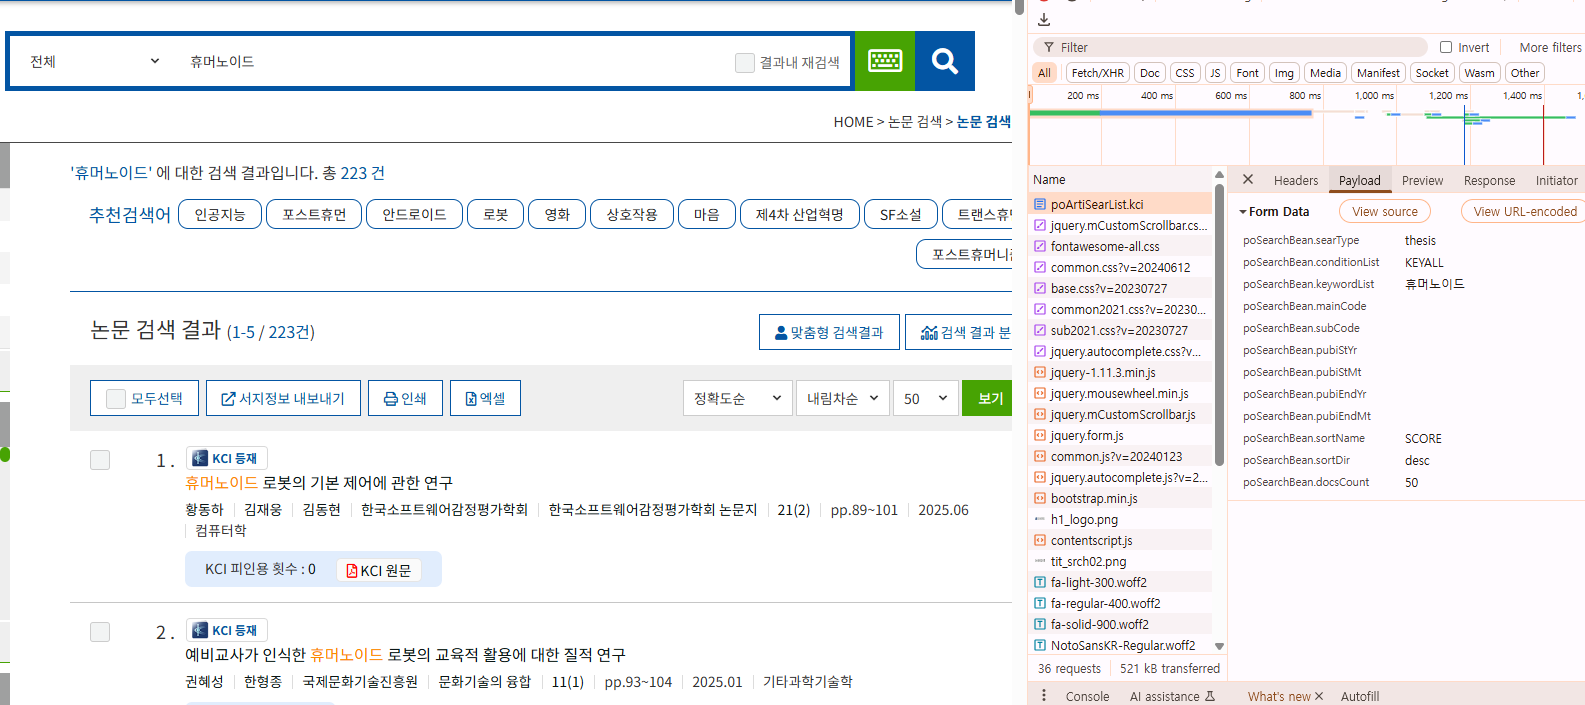

In [ ]:
# 논문수집 함수 정의
def crawl_papers_kci(search_keyword, num_papers):
    import requests as rq
    from bs4 import BeautifulSoup
    import pandas as pd
    import re
    import time


    # URL & payload
    url = 'https://www.kci.go.kr/kciportal/po/search/poArtiSearList.kci'
    headers = {'User-Agent': 'Mozilla/5.0'}
    payload = {
        'poSearchBean.searType': 'thesis',
        'poSearchBean.conditionList': 'KEYALL',
        'poSearchBean.keywordList': search_keyword,
        'poSearchBean.sortName': 'SCORE',
        'poSearchBean.sortDir': 'desc',
        'poSearchBean.startPg': 1,
        'poSearchBean.docsCount': num_papers
    }

    # 요청 & 파싱
    res = rq.post(url, data=payload, headers=headers)
    soup = BeautifulSoup(res.content, 'html.parser')

    # 논문 제목 링크 수집
    titles = soup.find_all('a', class_='subject')
    print(f'총 {len(titles)}개의 논문 제목 발견됨.')

    # 결과 저장용 리스트
    results = []

    for i, tag in enumerate(titles):
        try:
            print(f"{i+1}번째 논문 처리 중...")

            title = tag.text.strip()
            link = 'https://www.kci.go.kr' + tag.get('href')

            detail_res = rq.get(link, headers=headers)
            detail_soup = BeautifulSoup(detail_res.content, 'html.parser')

            # 정보 추출
            journal_tag = detail_soup.find('p', class_='jounal')
            journal = journal_tag.text.strip() if journal_tag else '없음'

            year_tag = detail_soup.find('p', class_='vol')
            year = year_tag.text.strip().split(',')[0] if year_tag else '없음'

            pub_tag = detail_soup.find('p', class_='pub')
            publisher = pub_tag.text.strip().split(':')[1].strip() if pub_tag else '없음'

            writer_tag = detail_soup.find('div', class_='author')
            if writer_tag:
                writers = re.findall(r'[가-힣]+', writer_tag.text.strip())
                writers = ", ".join(writers)
            else:
                writers = '없음'

            abs_tag = detail_soup.find('div', class_='innerBox open')
            abstracts = abs_tag.text.strip() if abs_tag else '없음'

            # 결과 누적
            results.append({
                'Title': title,
                'Writer': writers,
                'Publisher': publisher,
                'Year': year,
                'Journal': journal,
                'Abstract': abstracts,
                'Link': link
            })

            time.sleep(0.1)

        except Exception as e:
            print(f"에러 발생: {e}")
            continue

    df = pd.DataFrame(results)
    folder_path = f'/content/drive/MyDrive/{search_keyword}'
    # Check if the folder already exists
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f"Folder '{search_keyword}' created successfully in Google Drive.")
    else:
        print(f"Folder '{search_keyword}' already exists in Google Drive.")
        # 데이터프레임 생성 및 저장


    # CSV 파일로 저장
    csv_file = os.path.join(folder_path, f"{search_keyword}_학술논문(kci).csv")
    df.to_csv(csv_file, index=False, encoding='utf-8-sig')

    print(f"CSV 파일이 {csv_file}에 저장되었습니다.")

In [ ]:
# kci에서 keyword로 논문 수집하기 - 시간이 좀 걸립니다...7분 정도 소요
# kci에서 논문 수 확인하고 paper_num 뒤에 숫자 넣기
paper_num = 409
crawl_papers_kci(kci_keyword, paper_num)

총 409개의 논문 제목 발견됨.
1번째 논문 처리 중...
2번째 논문 처리 중...
3번째 논문 처리 중...
4번째 논문 처리 중...
5번째 논문 처리 중...
6번째 논문 처리 중...
7번째 논문 처리 중...
8번째 논문 처리 중...
9번째 논문 처리 중...
10번째 논문 처리 중...
11번째 논문 처리 중...
12번째 논문 처리 중...
13번째 논문 처리 중...
14번째 논문 처리 중...
15번째 논문 처리 중...
16번째 논문 처리 중...
17번째 논문 처리 중...
18번째 논문 처리 중...
19번째 논문 처리 중...
20번째 논문 처리 중...
21번째 논문 처리 중...
22번째 논문 처리 중...
23번째 논문 처리 중...
24번째 논문 처리 중...
25번째 논문 처리 중...
26번째 논문 처리 중...
27번째 논문 처리 중...
28번째 논문 처리 중...
29번째 논문 처리 중...
30번째 논문 처리 중...
31번째 논문 처리 중...
32번째 논문 처리 중...
33번째 논문 처리 중...
34번째 논문 처리 중...
35번째 논문 처리 중...
36번째 논문 처리 중...
37번째 논문 처리 중...
38번째 논문 처리 중...
39번째 논문 처리 중...
40번째 논문 처리 중...
41번째 논문 처리 중...
42번째 논문 처리 중...
43번째 논문 처리 중...
44번째 논문 처리 중...
45번째 논문 처리 중...
46번째 논문 처리 중...
47번째 논문 처리 중...
48번째 논문 처리 중...
49번째 논문 처리 중...
50번째 논문 처리 중...
51번째 논문 처리 중...
52번째 논문 처리 중...
53번째 논문 처리 중...
54번째 논문 처리 중...
55번째 논문 처리 중...
56번째 논문 처리 중...
57번째 논문 처리 중...
58번째 논문 처리 중...
59번째 논문 처리 중...
60번째 논문 처리 중...
61번째 논문 처리 중...
62번째 논문 처리 중..

In [ ]:
# 수집된 논문 기본 정보 확인하기
df_kci = pd.read_csv(f"/content/drive/MyDrive/{kci_keyword}/{kci_keyword}_학술논문(kci).csv")
df_kci.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 409 entries, 0 to 408
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Title      409 non-null    object
 1   Writer     408 non-null    object
 2   Publisher  409 non-null    object
 3   Year       409 non-null    object
 4   Journal    409 non-null    object
 5   Abstract   409 non-null    object
 6   Link       409 non-null    object
dtypes: object(7)
memory usage: 22.5+ KB


In [ ]:
# df_kci의 Abstracs를 Abstract로 바꾸기
df_kci.rename(columns={'Abstracts': 'Abstract'}, inplace=True)

In [ ]:
# 수집된 학위논문 처음 5개 확인하기
df_kci.head()

,Title,Writer,Publisher,Year,Journal,Abstract,Link
0,The Nature of Faith Education Amidst the Gener...,이수인,아신대학교 ACTS 신학연구소,2024,ACTS 신학저널,Technologies like ChatGPT are not merely tools...,https://www.kci.go.kr/kciportal/ci/sereArticle...
1,대학에서의 AI 활용 가이드라인 현황 및 설계 방향 연구: 생성형 AI(챗GPT)를...,김상철,목원대학교 교양교육혁신연구센터,2023,지식과 교양,본 연구에서는 본 연구에서는 현재 우리나라 주요 대학에서 제작 및 배포한 ‘AI 활...,https://www.kci.go.kr/kciportal/ci/sereArticle...
2,생성형 AI를 활용한 A1 수준 독일어 수업의 가능성 탐색: 챗GPT 3.5와 프롬...,권영숙,장로회신학대학교 세계선교연구원,2025,선교와신학,본 연구는 생성형 인공지능(Generative AI)인 챗GPT 3.5를 주요 AI...,https://www.kci.go.kr/kciportal/ci/sereArticle...
3,인공지능(AI)에 관한 뉴스 프레임 연구 : 미국과 영국 언론보도를 중심으로,문미리,한국국회학회,2025,한국과 세계,"본 연구는 미국과 영국의 주요 언론사인 뉴욕타임스, 워싱턴포스트, 더타임스, 가디언...",https://www.kci.go.kr/kciportal/ci/sereArticle...
4,인공지능(AI)을 활용한 한국어 수업 과정 연구 : <미디어 한국어> 수업에 적용,최권진,한국국제문화교류학회,2024,문화교류와 다문화교육,인공지능은 현시대에서 과학 기술 발전의 화두로 사람들의 일상생활에 깊숙하게 진입하고...,https://www.kci.go.kr/kciportal/ci/sereArticle...


### 2.분석대상 논문 선택


#### 2.1) 데이터 병합
- 📑 3개 파일 합치기

In [ ]:
# df_kci, df_hs, df_hw 3개 파일 합치기
df_all = pd.concat([df_kci, df_hs, df_hw], ignore_index=True)
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3843 entries, 0 to 3842
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Title       3843 non-null   object
 1   Writer      3842 non-null   object
 2   Publisher   2674 non-null   object
 3   Year        3843 non-null   object
 4   Journal     2674 non-null   object
 5   Abstract    3843 non-null   object
 6   Link        3843 non-null   object
 7   University  1169 non-null   object
 8   Degree      1169 non-null   object
dtypes: object(9)
memory usage: 270.3+ KB


In [ ]:
df_all.head()

,Title,Writer,Publisher,Year,Journal,Abstract,Link,University,Degree
0,The Nature of Faith Education Amidst the Gener...,이수인,아신대학교 ACTS 신학연구소,2024,ACTS 신학저널,Technologies like ChatGPT are not merely tools...,https://www.kci.go.kr/kciportal/ci/sereArticle...,NaN,NaN
1,대학에서의 AI 활용 가이드라인 현황 및 설계 방향 연구: 생성형 AI(챗GPT)를...,김상철,목원대학교 교양교육혁신연구센터,2023,지식과 교양,본 연구에서는 본 연구에서는 현재 우리나라 주요 대학에서 제작 및 배포한 ‘AI 활...,https://www.kci.go.kr/kciportal/ci/sereArticle...,NaN,NaN
2,생성형 AI를 활용한 A1 수준 독일어 수업의 가능성 탐색: 챗GPT 3.5와 프롬...,권영숙,장로회신학대학교 세계선교연구원,2025,선교와신학,본 연구는 생성형 인공지능(Generative AI)인 챗GPT 3.5를 주요 AI...,https://www.kci.go.kr/kciportal/ci/sereArticle...,NaN,NaN
3,인공지능(AI)에 관한 뉴스 프레임 연구 : 미국과 영국 언론보도를 중심으로,문미리,한국국회학회,2025,한국과 세계,"본 연구는 미국과 영국의 주요 언론사인 뉴욕타임스, 워싱턴포스트, 더타임스, 가디언...",https://www.kci.go.kr/kciportal/ci/sereArticle...,NaN,NaN
4,인공지능(AI)을 활용한 한국어 수업 과정 연구 : <미디어 한국어> 수업에 적용,최권진,한국국제문화교류학회,2024,문화교류와 다문화교육,인공지능은 현시대에서 과학 기술 발전의 화두로 사람들의 일상생활에 깊숙하게 진입하고...,https://www.kci.go.kr/kciportal/ci/sereArticle...,NaN,NaN


In [ ]:
# 마지막 5개
df_all.tail()

,Title,Writer,Publisher,Year,Journal,Abstract,Link,University,Degree
3838,한국 기본춤에 내재된 <예(禮)·도(道)> 와<무(武)·무(舞)>에 관한 연구,임정희,NaN,2013,NaN,ABSTRACT\r\n\r\nA Study on <Etiquette · Morali...,https://www.riss.kr/search/detail/DetailView.d...,세종대학교 대학원,국내박사
3839,韓日 兩國語의 外來語表記法에 關한 研究,김대영,NaN,2015,NaN,"Untill now, this research analyzes Japanese lo...",https://www.riss.kr/search/detail/DetailView.d...,東國大學校,국내박사
3840,GenAI 스타트업의 성공요인에 관한 탐색적 연구 : MAXQDA를 활용한 질적 내...,이현주,NaN,2024,NaN,This dissertation is an exploratory study on t...,https://www.riss.kr/search/detail/DetailView.d...,동국대학교 대학원,국내박사
3841,Analysis of economic growth-industrial activit...,"Lee, Daye",NaN,2022,NaN,"산업 혁명 이후의 급격한 산업화와 도시화는 경제 성장, 일자리 창출 및 빈곤 감소 ...",https://www.riss.kr/search/detail/DetailView.d...,울산대학교 대학원,국내박사
3842,朝鮮時代 道釋人物畵 硏究,최옥경,NaN,1991,NaN,초록이 없습니다.,https://www.riss.kr/search/detail/DetailView.d...,梨花女子大學校 敎育大學院,국내석사


#### 2.2) 중복논문 제거

In [ ]:
# 중복논문 확인 - 제목과 저널이 같은 논문 (학술논문과 학위논문의 제목이 같더라도 중복이 아닌 것으로 판단...)
df_all.duplicated(subset=['Title', 'Journal']).sum()

np.int64(133)

In [ ]:
# 중복논문 데이터 보기
df_all[df_all.duplicated(subset=['Title'], keep=False)].sort_values(by='Title')

,Title,Writer,Publisher,Year,Journal,Abstract,Link,University,Degree
326,<글쓰기멘토링>에서 Chat GPT 활용사례와 참여자 인식변화,"전현옥, 바로가기, 채민정",한국에듀테인먼트학회,2024,에듀테인먼트연구,본 연구는 대학에서 제공하고 있는 <글쓰기멘토링> 프로그램에서의 Chat GPT 활...,https://www.kci.go.kr/kciportal/ci/sereArticle...,NaN,NaN
2582,<글쓰기멘토링>에서 Chat GPT 활용사례와 참여자 인식변화,"전현옥,채민정",한국에듀테인먼트학회,2024,에듀테인먼트연구,본 연구는 대학에서 제공하고 있는 <글쓰기멘토링> 프로그램에서의 Chat GPT 활...,https://www.riss.kr/search/detail/DetailView.d...,NaN,NaN
817,AI 기반 챗봇 한국어 텍스트의 자연어 분석 및 한국어 교육 활용 모색 - 챗GPT...,왕감경,한국문화융합학회,2023,문화와 융합,The recent advancement of Artificial Intellige...,https://www.riss.kr/search/detail/DetailView.d...,NaN,NaN
63,AI 기반 챗봇 한국어 텍스트의 자연어 분석 및 한국어 교육 활용 모색 - 챗GPT...,왕감경,인문사회예술융합학회,2023,문화와융합,최근 인공지능(AI) 기술의 발전은 데이터와 컴퓨팅의 집합 덕분에 새로운 단계에 이...,https://www.kci.go.kr/kciportal/ci/sereArticle...,NaN,NaN
1518,AI 번역을 통한 한국어 의미 교육 연구,이지용(Jiyong Lee),현대문법학회,2023,현대문법연구,초록이 없습니다.,https://www.riss.kr/search/detail/DetailView.d...,NaN,NaN
...,...,...,...,...,...,...,...,...,...
1334,한국어교육 및 학습 도구로써 AI 활용 가능성 탐색 - 챗GPT를 중심으로 -,"류재원,소리나",한국문화융합학회,2023,문화와 융합,The purpose of this study is to recognize chan...,https://www.riss.kr/search/detail/DetailView.d...,NaN,NaN
115,한국어교육에서 챗GPT 활용 방안 연구 -한국문화 수업의 교육 자료 제작을 중심으로-,강소영,국제어문학회,2024,국제어문,이 연구는 한국어교육에서의 챗GPT 활용 가능성을 탐색하기 위해 실제 한국문화 수업...,https://www.kci.go.kr/kciportal/ci/sereArticle...,NaN,NaN
1339,한국어교육에서 챗GPT 활용 방안 연구 -한국문화 수업의 교육 자료 제작을 중심으로-,강소영 ( Kang So Yeong ),국제어문학회,2024,국제어문,This study aimed to create educational materia...,https://www.riss.kr/search/detail/DetailView.d...,NaN,NaN
1498,한시(漢詩) 독해(讀解) 교과의 생성형 AI 챗(Chat)GPT 활용 방안 고찰,박소영,한국고전연구학회,2024,한국고전연구,The process of reading and interpreting classi...,https://www.riss.kr/search/detail/DetailView.d...,NaN,NaN


In [ ]:
# 1. 중복논문 제거 - kci논문을 유지
df_drop_duplicates = df_all.drop_duplicates(subset=['Title', 'Journal'], keep='first')
df_drop_duplicates.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3710 entries, 0 to 3842
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Title       3710 non-null   object
 1   Writer      3709 non-null   object
 2   Publisher   2541 non-null   object
 3   Year        3710 non-null   object
 4   Journal     2541 non-null   object
 5   Abstract    3710 non-null   object
 6   Link        3710 non-null   object
 7   University  1169 non-null   object
 8   Degree      1169 non-null   object
dtypes: object(9)
memory usage: 289.8+ KB


#### 2.3) 관련없는 논문 제거
- ❌ 제목이나 초록에 humanoid, 휴머노이드란 단어가 없는 논문 제거

In [ ]:
# prompt: df_drop_duplicates에서 제목 또는 초록에 '휴머노이드' 또는 'Humanoid' (대소문자 구분 없음)가 없는 논문을 df_irrelevant에 저장

df_irrelevant = df_drop_duplicates[~df_drop_duplicates['Title'].str.contains('생성|ChatGPT|챗GPT|교육|수업', case=False, na=False) &
                                 ~df_drop_duplicates['Abstract'].str.contains('Title'].str.contains('생성|ChatGPT|챗GPT|교육|수업', case=False, na=False)]

SyntaxError: closing parenthesis ']' does not match opening parenthesis '(' (ipython-input-3018174659.py, line 4)

In [ ]:
# 제목과 초록에 모두 휴머노이드가 없는 논문들 확인
df_irrelevant

,Title,Writer,Publisher,Year,Journal,Abstract,Link,University,Degree
41,챗GPT 등장 이후 인공지능 환각 연구의 문헌 검토: 아카이브(arXiv)의 논문을...,"박대민, 바로가기, 이한종, 바로가기",한국지능정보사회진흥원,2024,정보화정책,환각은 대형언어모형이나 대형 멀티모달 모형의 활용을 막는 큰 장벽이다. 본 연구에서...,https://www.kci.go.kr/kciportal/ci/sereArticle...,NaN,NaN
148,인공지능 관련 규범 수립의 국내외 현황과 과제,이숙연,사단법인 법조협회,2023,법조,"인공지능은 단순반복작업에서 인간을 해방시켜 가고 있으며, 바둑과 같은 고차원적 영역...",https://www.kci.go.kr/kciportal/ci/sereArticle...,NaN,NaN
153,인공지능과 의지박약,"김다솜, 맹주만",중앙대학교 인공지능인문학연구소,2023,인공지능인문학연구,의지박약의 문제로부터 자유로운 “소크라테스-인간 유형”과 의지박약의 문제로 부터 자...,https://www.kci.go.kr/kciportal/ci/sereArticle...,NaN,NaN
159,인간과 인공지능의 동조: 덕 윤리를 통한 인공지능 윤리의 재구성,이희구,명지대학교(서울캠퍼스) 인문과학연구소,2023,인문과학연구논총,본 연구는 인공지능 윤리 문제를 덕 윤리를 통해 다시 정립하는 것을 목표로한다. 인...,https://www.kci.go.kr/kciportal/ci/sereArticle...,NaN,NaN
175,인공지능 AIVA와 프랑스의 AI 저작권 문제,김태희,프랑스학회,2024,프랑스학연구,"기술 혁신의 역사적 궤적을 고찰해보면, 인쇄술에서 AI에 이르기까지 모든 혁신적 기...",https://www.kci.go.kr/kciportal/ci/sereArticle...,NaN,NaN
...,...,...,...,...,...,...,...,...,...
3829,한글 글자의 시각적 체제화에 있어서의 자음의 역할,장은주,NaN,1984,NaN,초록이 없습니다.,https://www.riss.kr/search/detail/DetailView.d...,梨花女子大學校 大學院,국내석사
3833,한글지각 집단화에 있어서의 받침지각,이영숙,NaN,1986,NaN,초록이 없습니다.,https://www.riss.kr/search/detail/DetailView.d...,梨花女子大學校 大學院,국내석사
3835,아동에서 나타난 한글 글자의 視覺的 體制化,임혜숙,NaN,1988,NaN,초록이 없습니다.,https://www.riss.kr/search/detail/DetailView.d...,梨花女子大學校 敎育大學院,국내석사
3837,한국 문학 작품 『이루지 못한 꿈은 씨앗이 된다』 번역,타익 타잉 하,NaN,2024,NaN,초록이 없습니다.,https://www.riss.kr/search/detail/DetailView.d...,부산외국어대학교 일반대학원,국내석사


#### 2.4) 최종분석대상 논문 저장

In [ ]:
# df_drop_duplicates에서 df_irrelevant를 제외한 데이터를 df_all_filtered에 저장
df_all_filtered = df_drop_duplicates[~df_drop_duplicates.index.isin(df_irrelevant.index)]
df_all_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3563 entries, 0 to 3841
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Title       3563 non-null   object
 1   Writer      3562 non-null   object
 2   Publisher   2457 non-null   object
 3   Year        3563 non-null   object
 4   Journal     2457 non-null   object
 5   Abstract    3563 non-null   object
 6   Link        3563 non-null   object
 7   University  1106 non-null   object
 8   Degree      1106 non-null   object
dtypes: object(9)
memory usage: 278.4+ KB


In [ ]:
# df_all_filtered를 구글드라이브 keyword 폴더에 f'{keyword}_all_filtered.csv'로 저장

df_all_filtered.to_csv(f'/content/drive/MyDrive/{keyword}/{keyword}_all_filtered.csv', index=False, encoding='utf-8-sig')

### 3. 연구동향 파악
 - 연도별 논문수 분석/시각화
 - 저널별 논문수 분석/시각화
 - 학위별 논문수 분석/시각화

In [ ]:
# 최종분석 대상 논문 df로 불러오기
df  = pd.read_csv(f'/content/drive/MyDrive/{keyword}/{keyword}_all_filtered.csv')
df.head()

,Title,Writer,Publisher,Year,Journal,Abstract,Link,University,Degree
0,The Nature of Faith Education Amidst the Gener...,이수인,아신대학교 ACTS 신학연구소,2024,ACTS 신학저널,Technologies like ChatGPT are not merely tools...,https://www.kci.go.kr/kciportal/ci/sereArticle...,NaN,NaN
1,대학에서의 AI 활용 가이드라인 현황 및 설계 방향 연구: 생성형 AI(챗GPT)를...,김상철,목원대학교 교양교육혁신연구센터,2023,지식과 교양,본 연구에서는 본 연구에서는 현재 우리나라 주요 대학에서 제작 및 배포한 ‘AI 활...,https://www.kci.go.kr/kciportal/ci/sereArticle...,NaN,NaN
2,생성형 AI를 활용한 A1 수준 독일어 수업의 가능성 탐색: 챗GPT 3.5와 프롬...,권영숙,장로회신학대학교 세계선교연구원,2025,선교와신학,본 연구는 생성형 인공지능(Generative AI)인 챗GPT 3.5를 주요 AI...,https://www.kci.go.kr/kciportal/ci/sereArticle...,NaN,NaN
3,인공지능(AI)에 관한 뉴스 프레임 연구 : 미국과 영국 언론보도를 중심으로,문미리,한국국회학회,2025,한국과 세계,"본 연구는 미국과 영국의 주요 언론사인 뉴욕타임스, 워싱턴포스트, 더타임스, 가디언...",https://www.kci.go.kr/kciportal/ci/sereArticle...,NaN,NaN
4,인공지능(AI)을 활용한 한국어 수업 과정 연구 : <미디어 한국어> 수업에 적용,최권진,한국국제문화교류학회,2024,문화교류와 다문화교육,인공지능은 현시대에서 과학 기술 발전의 화두로 사람들의 일상생활에 깊숙하게 진입하고...,https://www.kci.go.kr/kciportal/ci/sereArticle...,NaN,NaN


In [ ]:
# matplotlib 한글폰트 라이브러리 설치
!pip install koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 45.3 MB/s eta 0:00:00


In [ ]:
# 데이터 시각화를 위한 라이브러리 설치
import koreanize_matplotlib     #한글설정
import matplotlib.pyplot as plt
import seaborn as sns

#### 3.1) 연도별 논문수 분석/시각화
📈생성형AI를 이용해서 날로 먹자~

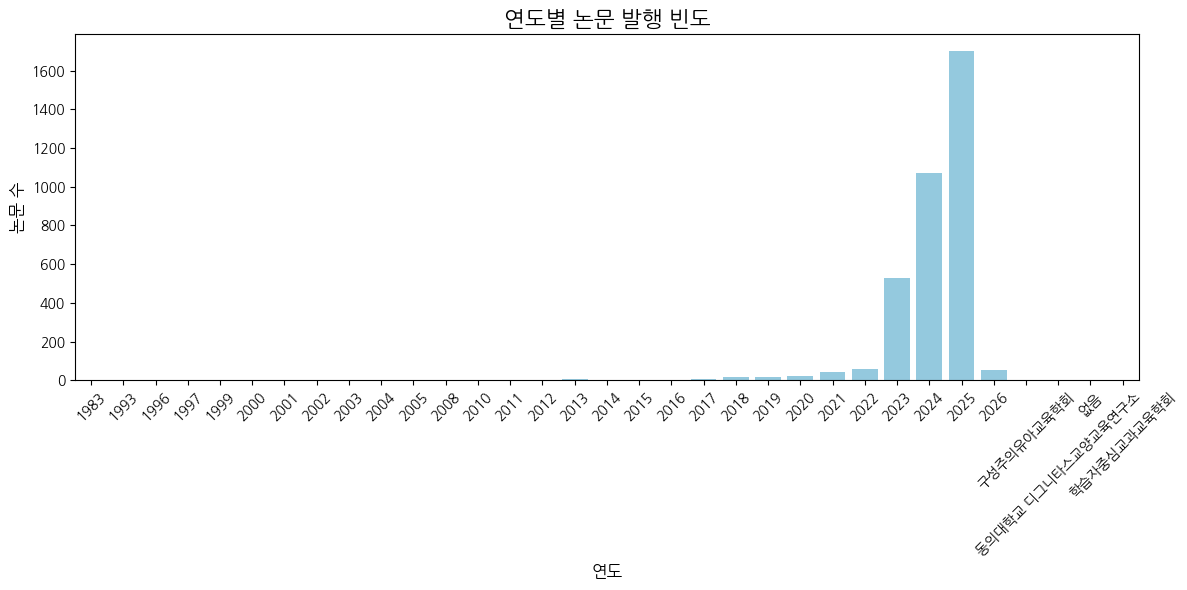

In [ ]:
# prompt: df.Year의 빈도수를 막대그래프로 시각화해줘

# 연도별 빈도수 계산
year_counts = df['Year'].value_counts().sort_index()

# 막대 그래프 시각화
plt.figure(figsize=(12, 6))
sns.barplot(x=year_counts.index, y=year_counts.values, color='skyblue')
plt.title('연도별 논문 발행 빈도', fontsize=16)
plt.xlabel('연도', fontsize=12)
plt.ylabel('논문 수', fontsize=12)
plt.xticks(rotation=45) # 연도 라벨 회전
plt.tight_layout()
plt.show()


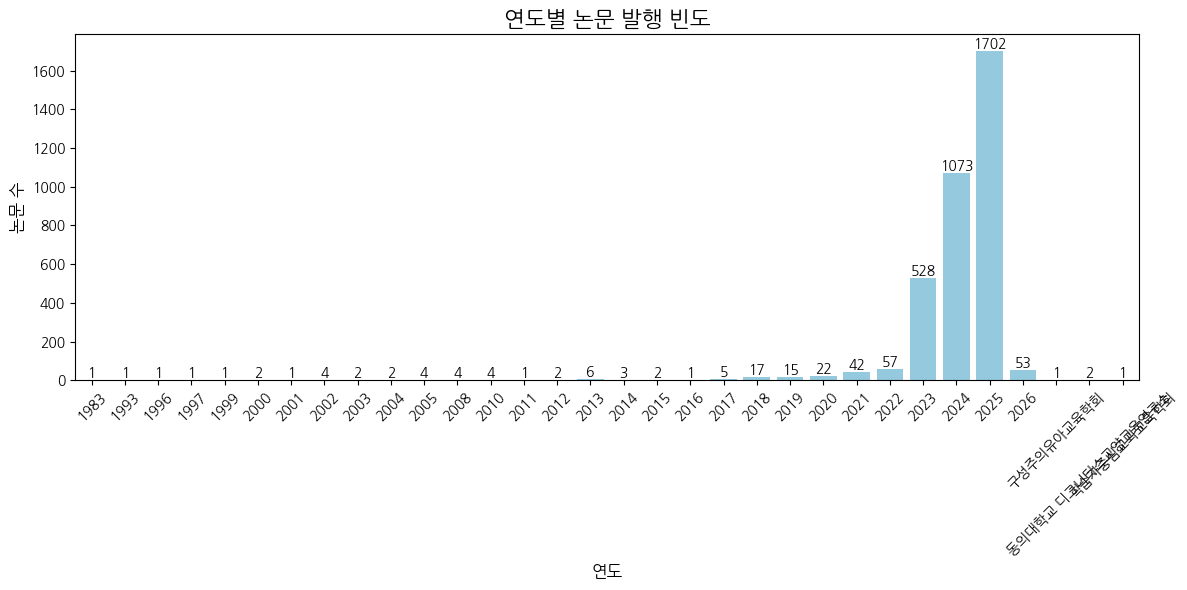

In [ ]:
# prompt: '없음'을 제거하고, 막대그래프 위에 논문수를 숫자로 표시해줘

# '없음' 데이터 제거 및 그래프 위에 논문 수 표시
year_counts_filtered = year_counts[year_counts.index != '없음']

# 막대 그래프 시각화
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=year_counts_filtered.index, y=year_counts_filtered.values, color='skyblue')
plt.title('연도별 논문 발행 빈도', fontsize=16)
plt.xlabel('연도', fontsize=12)
plt.ylabel('논문 수', fontsize=12)
plt.xticks(rotation=45) # 연도 라벨 회전

# 막대 그래프 위에 논문 수 표시
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()


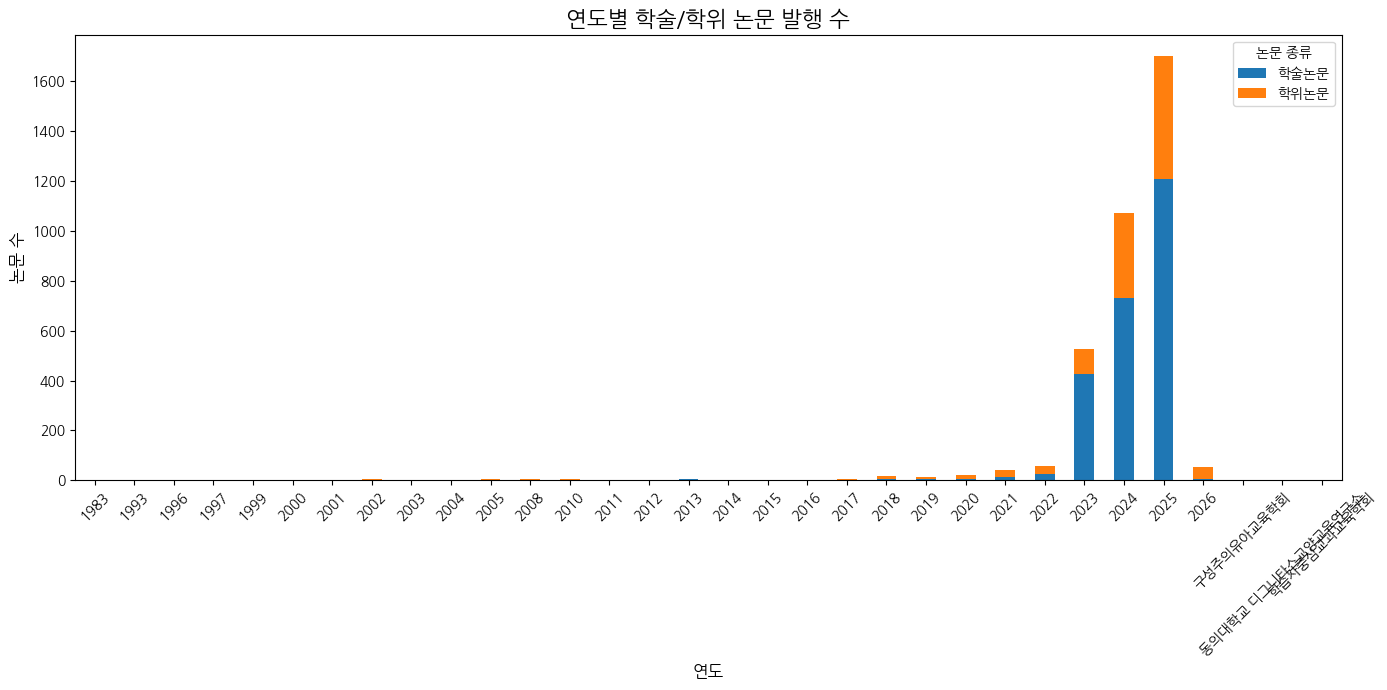

In [ ]:
# prompt: 학술논문과 학위논문을 구분하여 연도별 논문수를 시각화해줘. 학술논문은 Journal 칼럼이 있고, 학위논문은 University 칼럼이 있어

# 'Journal' 칼럼이 있는 논문은 학술논문, 'University' 칼럼이 있는 논문은 학위논문으로 구분
# 각 논문의 종류를 나타내는 'Type' 칼럼 생성
df['Type'] = df.apply(lambda row: '학술논문' if pd.notnull(row['Journal']) else ('학위논문' if pd.notnull(row['University']) else '기타'), axis=1)

# 연도별, 논문 종류별 빈도 계산
year_type_counts = df.groupby(['Year', 'Type']).size().unstack(fill_value=0)

# '없음' 데이터 제외
year_type_counts_filtered = year_type_counts.drop(index='없음', errors='ignore')

# 시각화
plt.figure(figsize=(14, 7))
year_type_counts_filtered.plot(kind='bar', stacked=True, figsize=(14, 7), ax=plt.gca())

plt.title('연도별 학술/학위 논문 발행 수', fontsize=16)
plt.xlabel('연도', fontsize=12)
plt.ylabel('논문 수', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='논문 종류')
plt.tight_layout()
plt.show()


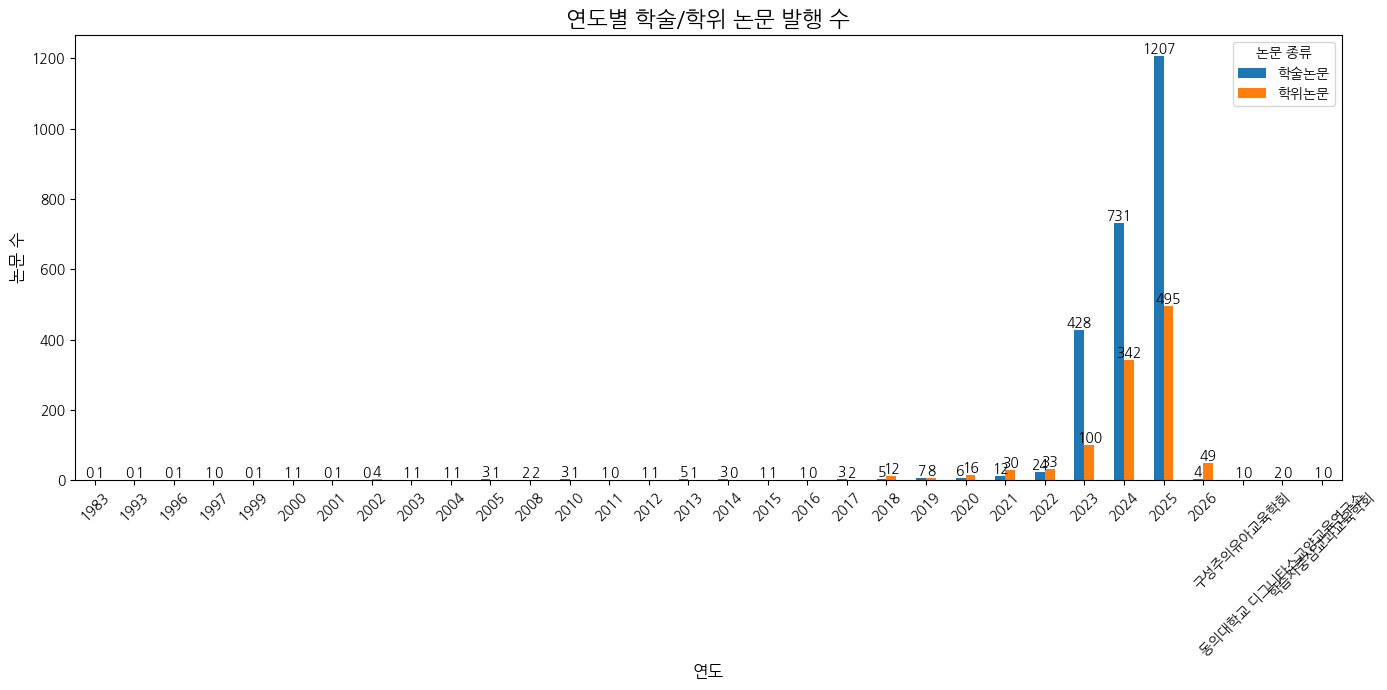

In [ ]:
# prompt: 학술과 학위 논문 수를 한 막대에 같이 그리지 말고, 나란히 그려줘

# 연도별, 논문 종류별 빈도 계산
year_type_counts = df.groupby(['Year', 'Type']).size().unstack(fill_value=0)

# '없음' 데이터 제외
year_type_counts_filtered = year_type_counts.drop(index='없음', errors='ignore')

# 시각화 - 학술과 학위 논문을 나란히 그리기
ax = year_type_counts_filtered[['학술논문', '학위논문']].plot(kind='bar', figsize=(14, 7))

plt.title('연도별 학술/학위 논문 발행 수', fontsize=16)
plt.xlabel('연도', fontsize=12)
plt.ylabel('논문 수', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='논문 종류')

# 막대 그래프 위에 논문 수 표시 (선택 사항)
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

#### 3.2) 학회별 논문수 분석/시각화

In [ ]:
# prompt: 상위 20개 학회 이름을 출력해줘

publisher_counts = df['Publisher'].value_counts().nlargest(20)
publisher_counts

,count
Publisher,
한국컴퓨터교육학회,75
한국정보교육학회,74
학습자중심교과교육학회,54
한국교육정보미디어학회,46
한국교양교육학회,40
국제문화기술진흥원,36
한국 리터러시 학회,33
한국컴퓨터정보학회,31
한국디지털콘텐츠학회,31


/tmp/ipython-input-2768716615.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=publisher_counts.values, y=publisher_counts.index, palette='viridis')


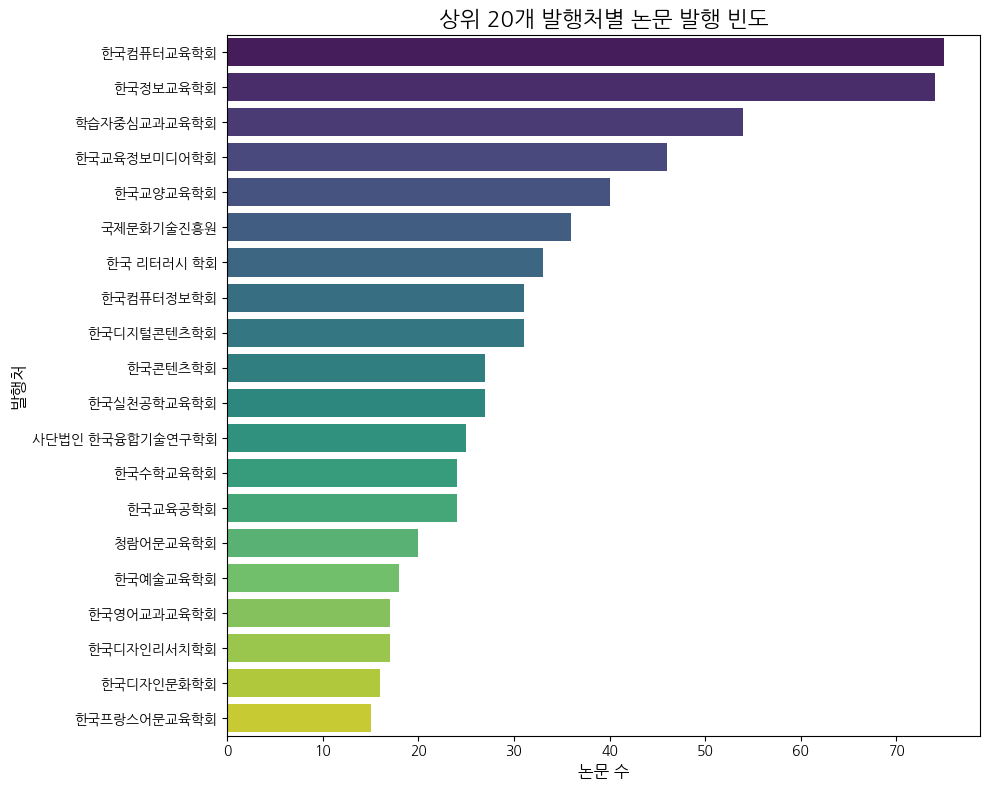

In [ ]:
# prompt: 제어·로봇·시스템학회를 제어로봇시스템학회로 통일시키고, df.Publisher의 상위 20개 빈도수를 가로막대그래프로 시각화해줘

df['Publisher'] = df['Publisher'].replace('제어·로봇·시스템학회', '제어로봇시스템학회')
publisher_counts = df['Publisher'].value_counts().nlargest(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=publisher_counts.values, y=publisher_counts.index, palette='viridis')
plt.title('상위 20개 발행처별 논문 발행 빈도', fontsize=16)
plt.xlabel('논문 수', fontsize=12)
plt.ylabel('발행처', fontsize=12)
plt.tight_layout()
plt.show()


/tmp/ipython-input-54815042.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=publisher_counts.values, y=publisher_counts.index, palette='viridis')


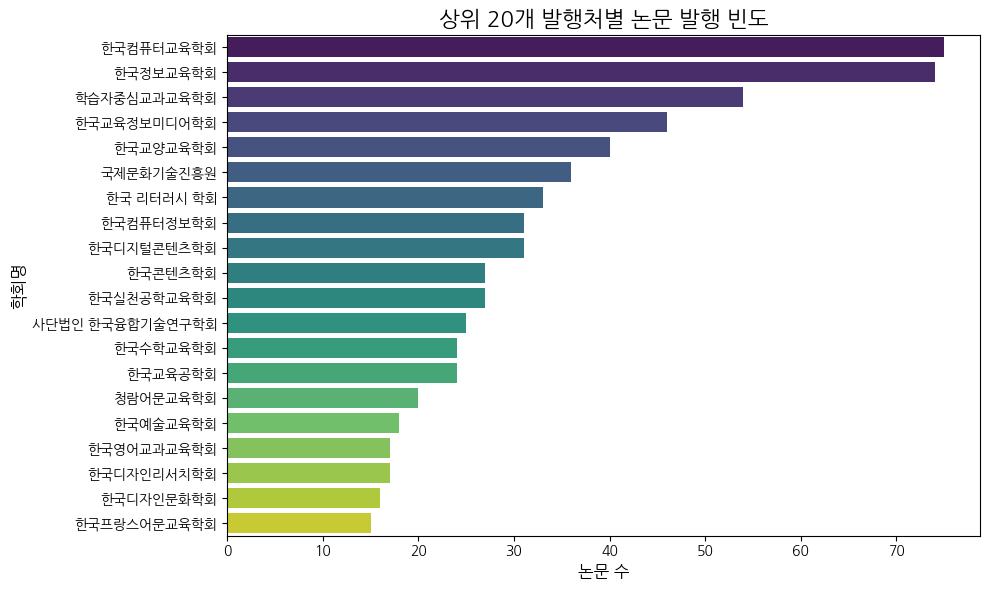

In [ ]:
# figsize=(10,6)으로 변경하여 위아래를 좀더 촘촘하게 그려보기
df['Publisher'] = df['Publisher'].replace('제어·로봇·시스템학회', '제어로봇시스템학회')
publisher_counts = df['Publisher'].value_counts().nlargest(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=publisher_counts.values, y=publisher_counts.index, palette='viridis')
plt.title('상위 20개 발행처별 논문 발행 빈도', fontsize=16)
plt.xlabel('논문 수', fontsize=12)
plt.ylabel('학회명', fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipython-input-2422877687.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=publisher_counts.values, y=publisher_counts.index, palette='viridis')


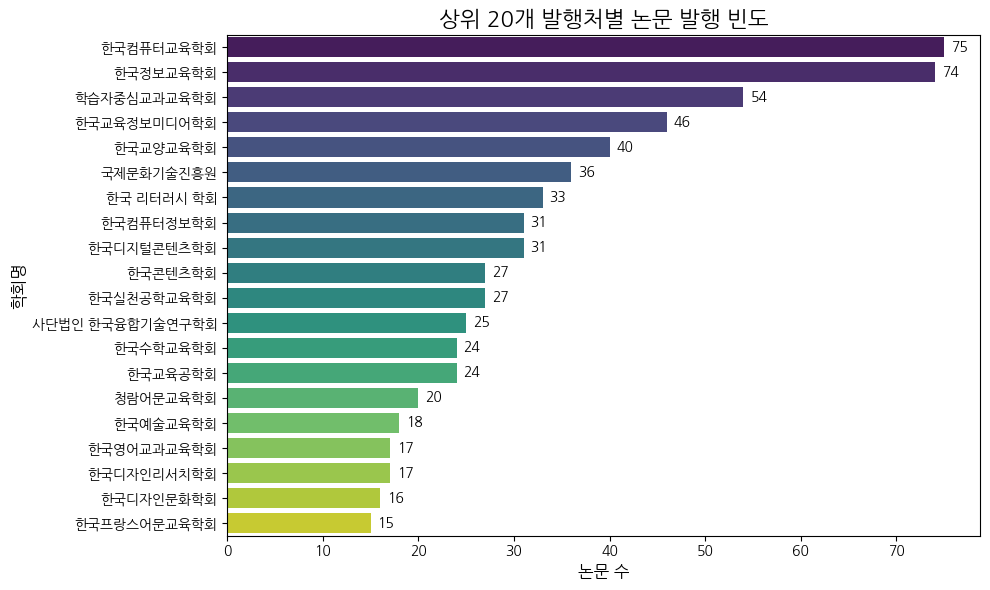

In [ ]:
# prompt: 바로 위 가로막대그래프 바 오른쪽 옆에 빈도수를 숫자로 표시

df['Publisher'] = df['Publisher'].replace('제어·로봇·시스템학회', '제어로봇시스템학회')
publisher_counts = df['Publisher'].value_counts().nlargest(20)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=publisher_counts.values, y=publisher_counts.index, palette='viridis')
plt.title('상위 20개 발행처별 논문 발행 빈도', fontsize=16)
plt.xlabel('논문 수', fontsize=12)
plt.ylabel('학회명', fontsize=12)

# 막대 그래프 위에 논문 수 표시
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=5) # padding으로 숫자 위치 조정

plt.tight_layout()
plt.show()


#### 3.3) 대학별 논문수 분석/시각화

/tmp/ipython-input-1796294941.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=university_counts.values, y=university_counts.index, palette='viridis')


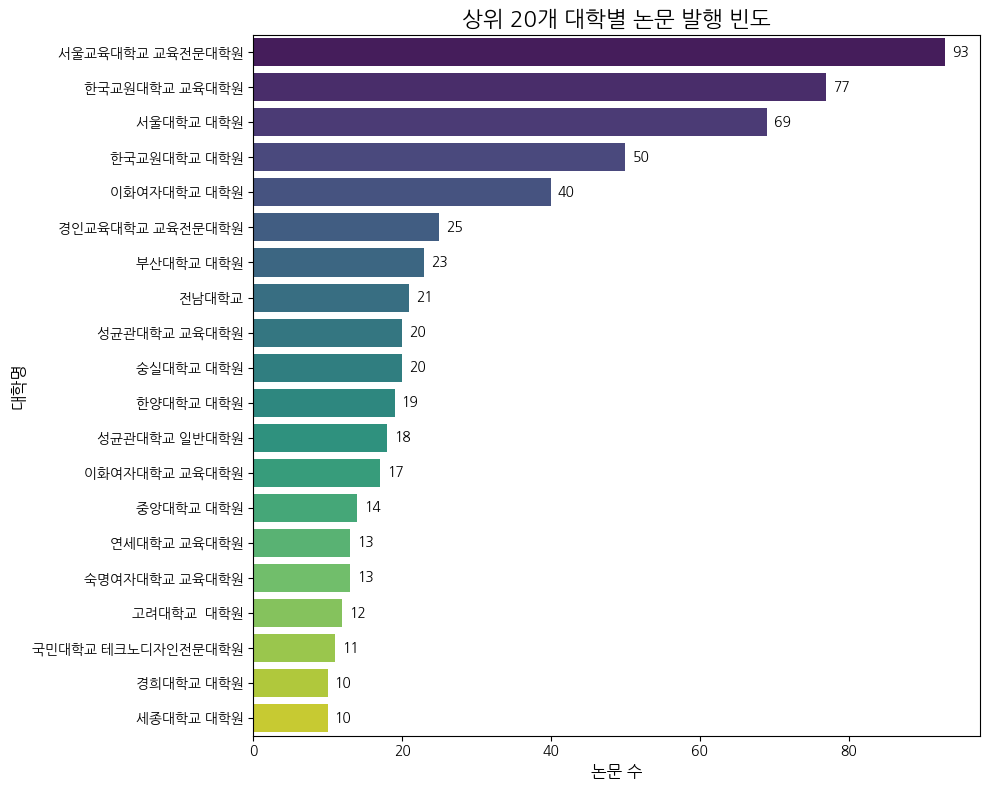

In [ ]:
# prompt: df.University의 빈도수를 계산해줘

university_counts = df['University'].value_counts().nlargest(20)

plt.figure(figsize=(10, 8))
ax = sns.barplot(x=university_counts.values, y=university_counts.index, palette='viridis')
plt.title('상위 20개 대학별 논문 발행 빈도', fontsize=16)
plt.xlabel('논문 수', fontsize=12)
plt.ylabel('대학명', fontsize=12)

# 막대 그래프 위에 논문 수 표시
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=5)

plt.tight_layout()
plt.show()


/tmp/ipython-input-2547108446.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=university_counts.values, y=university_counts.index, palette='viridis')


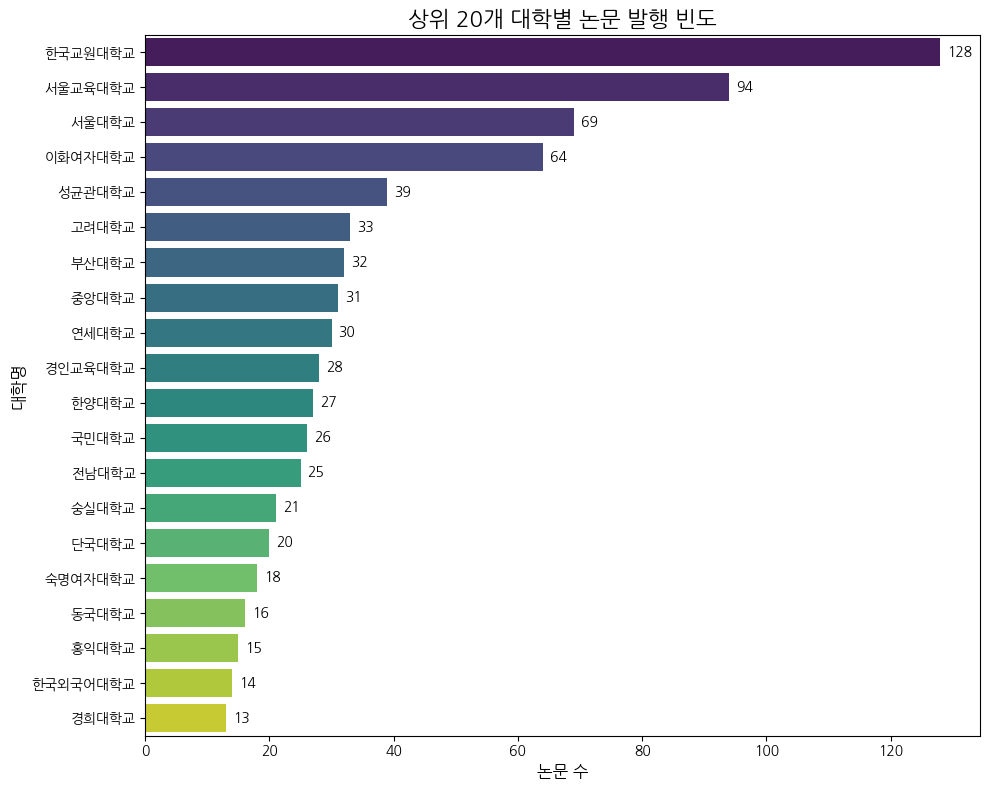

,count
University,
한국교원대학교,128
서울교육대학교,94
서울대학교,69
이화여자대학교,64
성균관대학교,39
고려대학교,33
부산대학교,32
중앙대학교,31
연세대학교,30


In [ ]:
# prompt: university_counts에서 忠南大學校 大學院은 충남대학교, Graduate School, Yonsei University는 연세대학교, 高麗大學校 大學院은 고려대학교로 바꿔줘.
# 그리고, 띄어쓰기 기준으로 나누고 앞의 단어들만 남겨줘 (대학원 제거)

university_counts = df['University'].replace({
    '忠南大學校 大學院': '충남대학교',
    'Graduate School, Yonsei University': '연세대학교',
    '高麗大學校 大學院': '고려대학교'
}).str.split().str[0].value_counts().nlargest(20)

plt.figure(figsize=(10, 8))
ax = sns.barplot(x=university_counts.values, y=university_counts.index, palette='viridis')
plt.title('상위 20개 대학별 논문 발행 빈도', fontsize=16)
plt.xlabel('논문 수', fontsize=12)
plt.ylabel('대학명', fontsize=12)

# 막대 그래프 위에 논문 수 표시
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=5)

plt.tight_layout()
plt.show()

university_counts


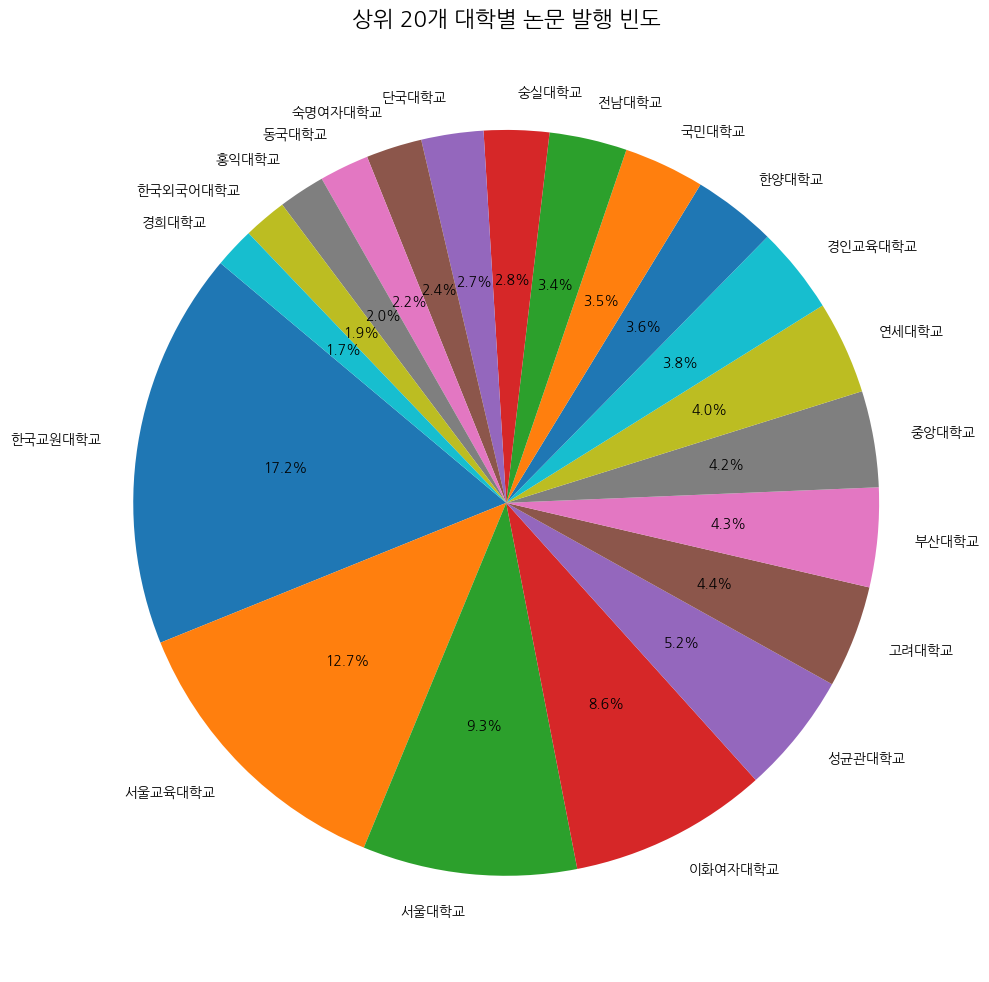

In [ ]:
# prompt: 위의 상위 20개 대학 빈도를 원 그래프로 바꿔줘

# 원 그래프 시각화
plt.figure(figsize=(10, 10))
plt.pie(university_counts.values, labels=university_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('상위 20개 대학별 논문 발행 빈도', fontsize=16)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()



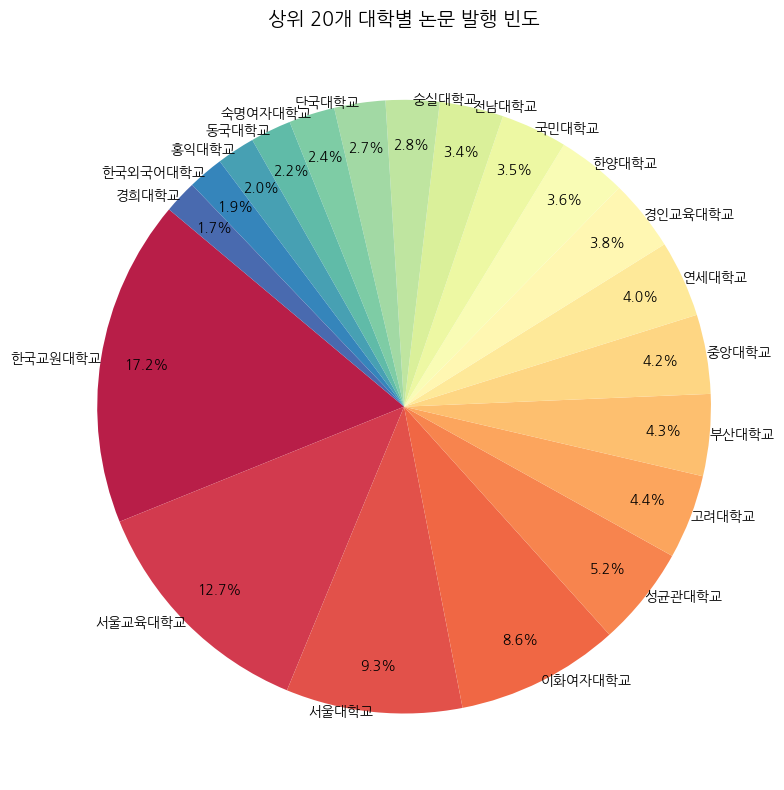

In [ ]:
# prompt: labels를 좀 더 원쪽으로 이동시키고, 원그래프 색상을 더 세련된 색상으로 교체

university_counts = df['University'].replace({
    '忠南大學校 大學院': '충남대학교',
    'Graduate School, Yonsei University': '연세대학교',
    '高麗大學校 大學院': '고려대학교'
}).str.split().str[0].value_counts().nlargest(20)

# 세련된 색상 팔레트 선택
colors = sns.color_palette('Spectral', len(university_counts))

plt.figure(figsize=(8, 8))
# labels 파라미터에 labeldistance 값을 조정하여 라벨 위치를 원쪽으로 이동
plt.pie(university_counts.values, labels=university_counts.index, autopct='%1.1f%%', startangle=140, colors=colors, pctdistance=0.85, labeldistance=1.00)
plt.title('상위 20개 대학별 논문 발행 빈도', fontsize=14)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()




#### 3.4) 학위별 논문수 분석/시각화

In [ ]:
# 석박사급 시각화
df.Degree.value_counts()

,count
Degree,
국내석사,830
국내박사,276


/tmp/ipython-input-1591033672.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=degree_counts.index, y=degree_counts.values, palette='viridis')


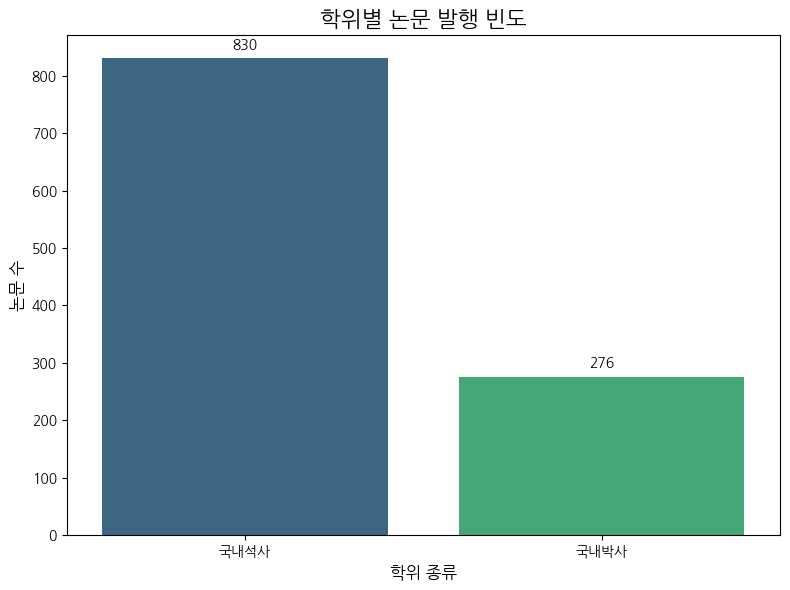

In [ ]:
# prompt: df.Degree를 시각화해줘

degree_counts = df.Degree.value_counts()

plt.figure(figsize=(8, 6))
ax = sns.barplot(x=degree_counts.index, y=degree_counts.values, palette='viridis')
plt.title('학위별 논문 발행 빈도', fontsize=16)
plt.xlabel('학위 종류', fontsize=12)
plt.ylabel('논문 수', fontsize=12)

# 막대 그래프 위에 논문 수 표시
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=5)

plt.tight_layout()
plt.show()


1부를 여기서 마치겠습니다.
수고하셨습니다.
